# distopt: Average-Case Smoothed Alignment (node–task assignment)

This notebook implements a **smoothed-analysis axis** for hardness driven by **node–task alignment**.

Setup (per graph kind and random seed):
- Sample a graph $W$ (path / cycle / ER / complete) and a fixed multiset of local quadratic tasks.
- Compute task scores from the base instance using $G_i = \nabla f_i(x^*)$.
- Build an **adversarial assignment** by sorting tasks by a PC1 score and placing them monotonically along the graph’s **Fiedler ordering**.
- **Smooth** the adversarial assignment by adding noise to the task scores:

$$
\texttt{scores\_noisy} = \texttt{scores} + \tau\,\mathrm{std}(\texttt{scores})\,z,\qquad z\sim\mathcal{N}(0,I),
$$

using one fixed $z$ per seed so the ordering changes progressively as $\tau$ grows.

We track:
- $\chi_{\mathrm{eff}} = \sum_{\lambda_k>0} \|v_k^\top G\|^2 / \lambda_k$ for $L = I-W$.
- For each algorithm: `mix_to_tol` and `grads_to_tol` to reach `||x̄ - x*|| <= tol_dist`.

Algorithms: **DGD**, **EXTRA**, **GradientTracking**, **MUDAG**.  
Hyperparameters are calibrated once per graph kind on the random-assignment end and then frozen for all $\tau$.

Notes:
- Path/cycle are the main signal; ER/complete may show weak effects.
- If runtime is high, reduce `seeds` or `GRAPH_KINDS` in the defaults cell.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Ensure repo root is on sys.path so `import research...` works no matter
# which working directory VS Code/Jupyter chooses for this notebook.
_here = Path().resolve()
_repo_root = None
for p in [_here, *_here.parents]:
    if (p / "pyproject.toml").exists():
        _repo_root = p
        break
if _repo_root is not None and str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from research.code.distopt.generators import (
    path_adjacency,
    cycle_adjacency,
    complete_adjacency,
    erdos_renyi_adjacency,
    make_graph_from_adjacency,
    make_wishart_ridge_problem,
)
from research.code.distopt.algorithms import DGD, EXTRA, GradientTracking, MUDAG
from research.code.distopt.problems import DistributedQuadraticProblem
from research.code.distopt.runner import run_experiment, MaxMixRounds, TargetXStarDist

In [2]:
# --------- minimal helpers (adapted from default_experiments / structural_metrics) ---------

def _consensus_init(X: np.ndarray) -> np.ndarray:
    """Return consensus initialization with the same average as X."""
    x0_bar = np.mean(X, axis=0)
    return np.repeat(x0_bar[None, :], X.shape[0], axis=0)


def make_connected_er_graph(n: int, p: float, *, seed: int, lazy: float, max_tries: int = 50):
    for k in range(max_tries):
        adj = erdos_renyi_adjacency(n, p, seed=seed + k)
        graph = make_graph_from_adjacency(adj, lazy=lazy)
        if bool(graph.ensure_stats().connected):
            return graph
    raise RuntimeError("Failed to sample a connected ER graph; increase max_tries or p")


def alpha_from_factor(problem: DistributedQuadraticProblem, factor: float) -> float:
    L_l = float(problem.ensure_stats().L_l)
    return float(factor) / L_l


def permute_problem(problem: DistributedQuadraticProblem, perm: np.ndarray) -> DistributedQuadraticProblem:
    perm = np.asarray(perm, dtype=int)
    if perm.shape != (problem.n,):
        raise ValueError("perm must have shape (n,)")
    return DistributedQuadraticProblem(
        graph=problem.graph,
        A=problem.A[perm],
        b=problem.b[perm],
        validate=True,
        tol=problem.tol,
        metadata={**problem.metadata, "perm_kind": "custom"},
    )


def _final_dist_to_x_star(res, *, problem: DistributedQuadraticProblem) -> float:
    x_bar = np.asarray(res.final["x_bar"], dtype=np.float64)
    return float(np.linalg.norm(x_bar - problem.x_star))


def run_to_tol(
    problem: DistributedQuadraticProblem,
    alg: object,
    *,
    X0: np.ndarray,
    max_mix: int,
    tol_dist: float,
    log_every: int,
):
    res = run_experiment(
        problem,
        alg,
        stop=[MaxMixRounds(int(max_mix)), TargetXStarDist(float(tol_dist))],
        X0=X0,
        log_every=int(log_every),
    )
    dist_final = _final_dist_to_x_star(res, problem=problem)
    reached = bool(dist_final <= float(tol_dist))

    mix_to_tol = float(res.final["mix_rounds"]) if reached else float("inf")
    grads_to_tol = float(res.final["grad_evals_per_node"]) if reached else float("inf")

    return res, {
        "reached": reached,
        "dist_final": float(dist_final),
        "mix_to_tol": float(mix_to_tol),
        "grads_to_tol": float(grads_to_tol),
    }


def median_with_infs(xs: list[float]) -> float:
    arr = np.asarray(xs, dtype=float)
    if arr.size == 0:
        return float("nan")
    return float(np.median(arr))


def median_finite_or_nan(xs: list[float]) -> float:
    arr = np.asarray(xs, dtype=float)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return float("nan")
    return float(np.median(finite))

In [3]:
# --------- structural metrics: χ_eff + ordering primitives ---------

def grad_heterogeneity_at_x_star(problem: DistributedQuadraticProblem) -> np.ndarray:
    x = problem.x_star
    return np.einsum("ijk,k->ij", problem.A, x) - problem.b


def chi_eff_from_G(graph, G: np.ndarray, *, tol: float | None = None):
    """Return χ_eff = sum_{λ_k>0} ||v_k^T G||^2 / λ_k for L = I-W.

    G is (n,d). This sums the per-dimension pseudoinverse quadratic form.
    """
    if tol is None:
        tol = float(getattr(graph, "tol", 1e-12))
    L = graph.L
    eigvals, V = np.linalg.eigh(L)
    proj = V.T @ G  # (n,d)
    energy = np.sum(proj**2, axis=1)  # per mode
    inv = np.zeros_like(eigvals)
    inv[eigvals > tol] = 1.0 / eigvals[eigvals > tol]
    contrib = inv * energy
    return float(np.sum(contrib)), {"eigvals": eigvals, "energy": energy, "contrib": contrib}


def fiedler_order(graph, *, tol: float | None = None) -> np.ndarray:
    if tol is None:
        tol = float(getattr(graph, "tol", 1e-12))
    eigvals, V = np.linalg.eigh(graph.L)
    pos = np.flatnonzero(eigvals > tol)
    if pos.size == 0:
        return np.arange(graph.n)
    idx = int(pos[0])  # smallest positive eigenvalue
    v = V[:, idx]
    return np.argsort(v)


def pc1_task_score(G: np.ndarray) -> np.ndarray:
    Gc = G - np.mean(G, axis=0, keepdims=True)
    _u, _s, vt = np.linalg.svd(Gc, full_matrices=False)
    pc1 = vt[0]
    return Gc @ pc1

In [4]:
# --------- smoothed assignment axis (τ-jitter) ---------

def adversarial_perm(graph, scores: np.ndarray) -> np.ndarray:
    nodes = fiedler_order(graph)
    tasks_sorted = np.argsort(scores)
    perm = np.empty(int(graph.n), dtype=int)
    perm[nodes] = tasks_sorted
    return perm


def smoothed_perm(graph, scores: np.ndarray, tau: float, z: np.ndarray) -> np.ndarray:
    scale = float(np.std(scores))
    if scale == 0.0:
        scale = 1.0
    scores_noisy = np.asarray(scores, dtype=float) + float(tau) * scale * np.asarray(z, dtype=float)
    return adversarial_perm(graph, scores_noisy)

In [5]:
# --------- global defaults ---------

seeds = [0, 1, 2]
n = 20
d = 20

# Lazification makes W PSD, which MUDAG requires.
lazy = 0.5

max_mix = 5000
log_every = 10
tol_dist = 1e-3

tau_grid = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]

alpha_factors = [0.02, 0.05, 0.1, 0.2]
c_K_grid = [0.5, 1.0, 2.0, 3.0]

problem_kwargs = dict(m_per_node=50, lambda_reg=1.0, noise_std=0.0)

GRAPH_KINDS = ['path', 'cycle', 'er', 'complete']
ALGS = ['DGD', 'EXTRA', 'GT', 'MUDAG']

print('seeds:', seeds)
print('n,d:', (n, d), 'lazy:', lazy)
print('max_mix:', max_mix, 'log_every:', log_every, 'tol_dist:', tol_dist)
print('tau_grid:', tau_grid)

seeds: [0, 1, 2]
n,d: (20, 20) lazy: 0.5
max_mix: 5000 log_every: 10 tol_dist: 0.001
tau_grid: [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]


In [6]:
def make_graph(kind: str, *, seed: int):
    if kind == 'path':
        return make_graph_from_adjacency(path_adjacency(n), lazy=lazy)
    if kind == 'cycle':
        return make_graph_from_adjacency(cycle_adjacency(n), lazy=lazy)
    if kind == 'complete':
        return make_graph_from_adjacency(complete_adjacency(n), lazy=lazy)
    if kind == 'er':
        # p chosen so it’s typically connected at n=20.
        return make_connected_er_graph(n, p=0.25, seed=seed, lazy=lazy)
    raise ValueError(f'Unknown graph kind={kind!r}')


def make_base_problem(graph, *, seed: int) -> DistributedQuadraticProblem:
    return make_wishart_ridge_problem(graph, d=d, seed=seed, **problem_kwargs)

In [7]:
# --------- hyperparameter calibration on the RANDOM assignment end only ---------

def pick_best_hp(summary_rows: list[dict[str, object]]):
    finite = [r for r in summary_rows if np.isfinite(float(r['med_mix_to_tol']))]
    if finite:
        return finite[0]['hp']
    return min(summary_rows, key=lambda r: float(r['med_final_dist']))['hp']


def calibrate_hyperparams_for_graph(kind: str) -> dict[str, object]:
    base = {}  # seed -> (graph, problem_random_perm, X0)
    for seed in seeds:
        graph = make_graph(kind, seed=int(seed))
        base_problem = make_base_problem(graph, seed=int(seed))
        rng = np.random.default_rng(int(seed))
        X0 = _consensus_init(rng.normal(size=(base_problem.n, base_problem.d)))
        perm = rng.permutation(base_problem.n)
        pr = permute_problem(base_problem, perm)
        base[int(seed)] = (graph, pr, X0)

    rows_by_alg = {}

    def _run_sweep(alg_name: str, hp_grid: list[float]) -> list[dict[str, object]]:
        out = []
        for hp in hp_grid:
            mix_to = []
            grad_to = []
            final_dist = []
            for seed, (_g, pr, X0) in base.items():
                if alg_name == 'DGD':
                    alg = DGD(alpha=alpha_from_factor(pr, float(hp)))
                elif alg_name == 'EXTRA':
                    alg = EXTRA(alpha=alpha_from_factor(pr, float(hp)))
                elif alg_name == 'GT':
                    alg = GradientTracking(alpha=alpha_from_factor(pr, float(hp)))
                elif alg_name == 'MUDAG':
                    alg = MUDAG(c_K=float(hp))
                else:
                    raise ValueError(alg_name)

                alg.check(pr)
                res, summ = run_to_tol(pr, alg, X0=X0, max_mix=max_mix, tol_dist=tol_dist, log_every=log_every)
                mix_to.append(float(summ['mix_to_tol']))
                grad_to.append(float(summ['grads_to_tol']))
                final_dist.append(float(summ['dist_final']))

            out.append({
                'hp': float(hp),
                'med_mix_to_tol': float(np.median(np.asarray(mix_to, dtype=float))),
                'med_grads_to_tol': float(np.median(np.asarray(grad_to, dtype=float))),
                'med_final_dist': float(np.median(np.asarray(final_dist, dtype=float))),
            })

        out.sort(key=lambda r: (float(r['med_mix_to_tol']), float(r['med_grads_to_tol']), float(r['med_final_dist'])))
        return out

    rows_by_alg['DGD'] = _run_sweep('DGD', alpha_factors)
    rows_by_alg['EXTRA'] = _run_sweep('EXTRA', alpha_factors)
    rows_by_alg['GT'] = _run_sweep('GT', alpha_factors)
    rows_by_alg['MUDAG'] = _run_sweep('MUDAG', c_K_grid)

    best = {alg: pick_best_hp(rows) for alg, rows in rows_by_alg.items()}
    return {'best': best, 'sweeps': rows_by_alg}

In [8]:
# --------- Experiment: smoothed alignment fragility ---------

all_rows: list[dict[str, object]] = []
chi_rows: list[dict[str, object]] = []
energy_diags: dict[tuple[str, int, float], dict[str, np.ndarray]] = {}

calib_by_kind: dict[str, dict[str, object]] = {}
for kind in GRAPH_KINDS:
    print(f"\nCalibrating hyperparameters for: {kind}")
    calib = calibrate_hyperparams_for_graph(kind)
    calib_by_kind[kind] = calib
    print("  best:", calib["best"])

for kind in GRAPH_KINDS:
    best = calib_by_kind[kind]["best"]
    print(f"\nRunning smoothed-alignment sweep for: {kind}")

    for seed in seeds:
        graph = make_graph(kind, seed=int(seed))
        base_problem = make_base_problem(graph, seed=int(seed))
        rng = np.random.default_rng(int(seed))
        X0 = _consensus_init(rng.normal(size=(base_problem.n, base_problem.d)))

        G_base = grad_heterogeneity_at_x_star(base_problem)
        scores = pc1_task_score(G_base)

        # One fixed noise vector per seed so the ordering changes progressively with tau.
        z = rng.normal(size=base_problem.n)

        for tau in tau_grid:
            tau = float(tau)

            perm = smoothed_perm(graph, scores, tau, z)
            pr = permute_problem(base_problem, perm)

            chi_eff, diag = chi_eff_from_G(graph, grad_heterogeneity_at_x_star(pr))
            chi_rows.append({"kind": kind, "seed": int(seed), "tau": tau, "chi_eff": float(chi_eff)})

            if (
                kind in ["path", "cycle"]
                and int(seed) == int(seeds[0])
                and tau in [float(tau_grid[0]), float(tau_grid[-1])]
            ):
                energy_diags[(kind, int(seed), float(tau))] = diag

            # Run algorithms with frozen hyperparameters.
            for alg_name in ALGS:
                if alg_name == "DGD":
                    alg = DGD(alpha=alpha_from_factor(pr, float(best["DGD"])))
                elif alg_name == "EXTRA":
                    alg = EXTRA(alpha=alpha_from_factor(pr, float(best["EXTRA"])))
                elif alg_name == "GT":
                    alg = GradientTracking(alpha=alpha_from_factor(pr, float(best["GT"])))
                elif alg_name == "MUDAG":
                    alg = MUDAG(c_K=float(best["MUDAG"]))
                else:
                    raise ValueError(alg_name)

                alg.check(pr)
                _res, summ = run_to_tol(pr, alg, X0=X0, max_mix=max_mix, tol_dist=tol_dist, log_every=log_every)

                all_rows.append(
                    {
                        "kind": kind,
                        "seed": int(seed),
                        "tau": tau,
                        "chi_eff": float(chi_eff),
                        "alg": alg_name,
                        "mix_to_tol": float(summ["mix_to_tol"]),
                        "grads_to_tol": float(summ["grads_to_tol"]),
                        "dist_final": float(summ["dist_final"]),
                    }
                )

print("\nDone.")
print("  rows:", len(all_rows))
print("  chi_rows:", len(chi_rows))
print("  diags:", len(energy_diags))


Calibrating hyperparameters for: path
  best: {'DGD': 0.02, 'EXTRA': 0.2, 'GT': 0.02, 'MUDAG': 1.0}

Calibrating hyperparameters for: cycle
  best: {'DGD': 0.02, 'EXTRA': 0.2, 'GT': 0.05, 'MUDAG': 1.0}

Calibrating hyperparameters for: er
  best: {'DGD': 0.02, 'EXTRA': 0.2, 'GT': 0.2, 'MUDAG': 0.5}

Calibrating hyperparameters for: complete
  best: {'DGD': 0.02, 'EXTRA': 0.2, 'GT': 0.2, 'MUDAG': 0.5}

Running smoothed-alignment sweep for: path

Running smoothed-alignment sweep for: cycle

Running smoothed-alignment sweep for: er

Running smoothed-alignment sweep for: complete

Done.
  rows: 336
  chi_rows: 84
  diags: 4


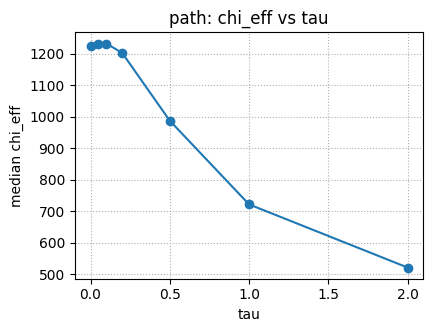

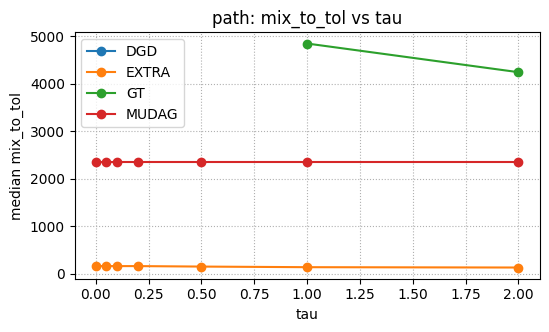

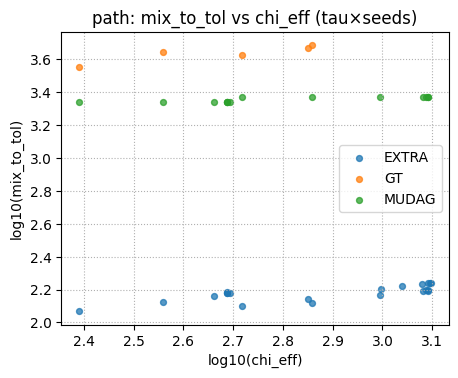

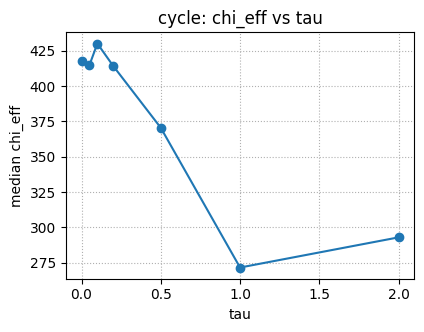

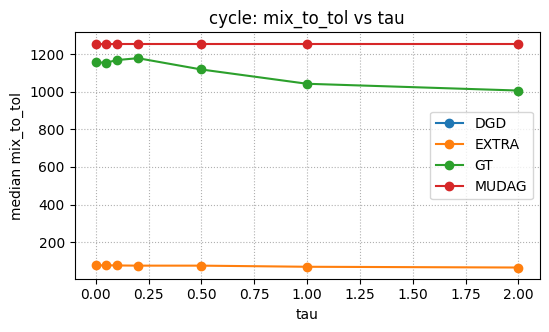

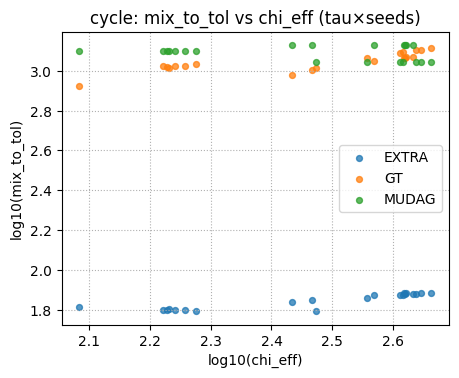

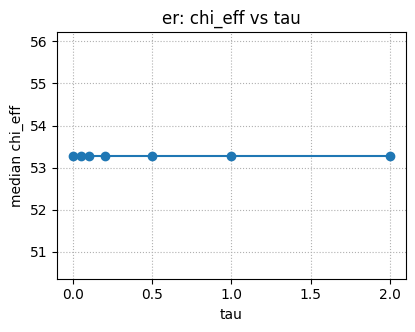

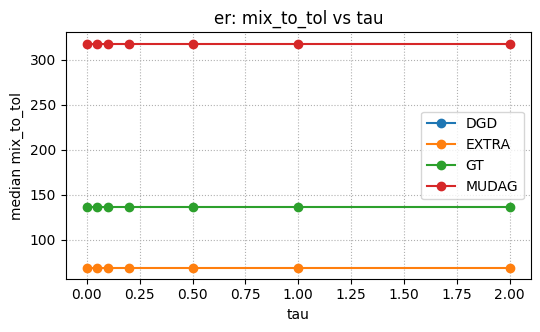

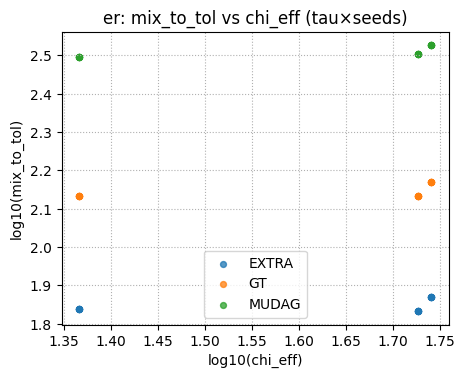

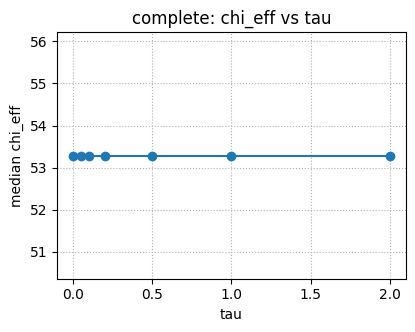

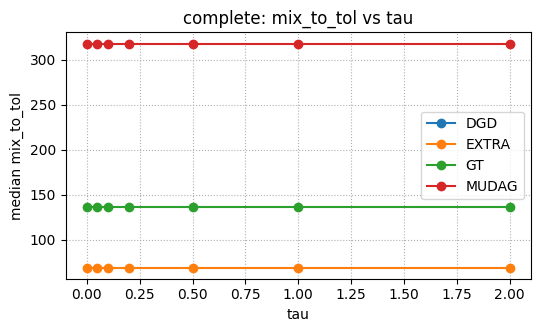

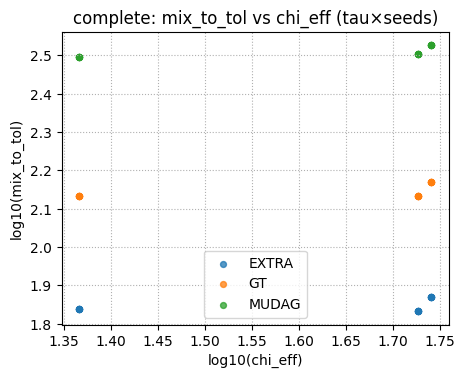

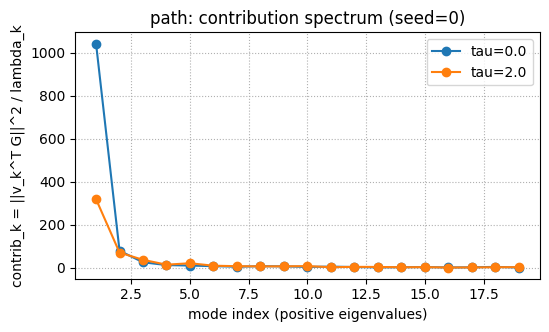

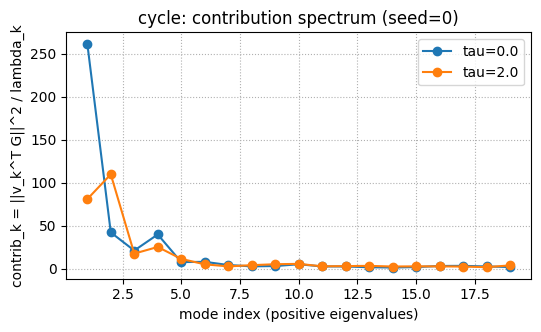

In [9]:
# --------- Plots: χ_eff(τ) and performance(τ) ---------

for kind in GRAPH_KINDS:
    # χ_eff vs τ (median over seeds)
    chi_med = []
    for tau in tau_grid:
        vals = [
            float(r["chi_eff"])
            for r in chi_rows
            if r["kind"] == kind and float(r["tau"]) == float(tau)
        ]
        chi_med.append(float(np.median(np.asarray(vals, dtype=float))))

    plt.figure(figsize=(4.5, 3.2))
    plt.plot(tau_grid, chi_med, marker="o")
    plt.xlabel("tau")
    plt.ylabel("median chi_eff")
    plt.title(f"{kind}: chi_eff vs tau")
    plt.grid(True, ls=":")
    plt.show()

    # mix_to_tol vs τ (median over seeds; inf -> nan in plot)
    plt.figure(figsize=(6.0, 3.2))
    for alg_name in ALGS:
        meds = []
        for tau in tau_grid:
            vals = [
                float(r["mix_to_tol"])
                for r in all_rows
                if r["kind"] == kind and r["alg"] == alg_name and float(r["tau"]) == float(tau)
            ]
            med = median_with_infs(vals)
            meds.append(np.nan if not np.isfinite(med) else med)
        plt.plot(tau_grid, meds, marker="o", label=alg_name)

    plt.xlabel("tau")
    plt.ylabel("median mix_to_tol")
    plt.title(f"{kind}: mix_to_tol vs tau")
    plt.grid(True, ls=":")
    plt.legend()
    plt.show()

    # Scatter: log10(mix_to_tol) vs log10(chi_eff) over (tau × seeds)
    plt.figure(figsize=(5.0, 3.8))
    for alg_name in ALGS:
        xs = []
        ys = []
        for r in all_rows:
            if r["kind"] != kind or r["alg"] != alg_name:
                continue
            chi = float(r["chi_eff"])
            mix = float(r["mix_to_tol"])
            if not (np.isfinite(chi) and np.isfinite(mix) and chi > 0.0 and mix > 0.0):
                continue
            xs.append(np.log10(chi))
            ys.append(np.log10(mix))
        if xs:
            plt.scatter(xs, ys, s=18, alpha=0.75, label=alg_name)

    plt.xlabel("log10(chi_eff)")
    plt.ylabel("log10(mix_to_tol)")
    plt.title(f"{kind}: mix_to_tol vs chi_eff (tau×seeds)")
    plt.grid(True, ls=":")
    plt.legend()
    plt.show()


# --------- Contribution spectrum diagnostic (path & cycle) ---------

tol = 1e-12
seed0 = int(seeds[0])
tau0 = float(tau_grid[0])
tau1 = float(tau_grid[-1])

for kind in ["path", "cycle"]:
    key0 = (kind, seed0, tau0)
    key1 = (kind, seed0, tau1)
    if key0 not in energy_diags or key1 not in energy_diags:
        continue

    d0 = energy_diags[key0]
    d1 = energy_diags[key1]

    eig = np.asarray(d0["eigvals"], dtype=float)
    mask = eig > tol
    idx = np.arange(eig.size)[mask]

    c0 = np.asarray(d0["contrib"], dtype=float)[mask]
    c1 = np.asarray(d1["contrib"], dtype=float)[mask]

    plt.figure(figsize=(6.0, 3.2))
    plt.plot(idx, c0, marker="o", label=f"tau={tau0}")
    plt.plot(idx, c1, marker="o", label=f"tau={tau1}")
    plt.xlabel("mode index (positive eigenvalues)")
    plt.ylabel("contrib_k = ||v_k^T G||^2 / lambda_k")
    plt.title(f"{kind}: contribution spectrum (seed={seed0})")
    plt.grid(True, ls=":")
    plt.legend()
    plt.show()

## Interpretation (what this does / does not test)

- This experiment isolates a **node-space mechanism**: how heterogeneity at $x^*$ aligns with slow graph Laplacian modes (via $\chi_{\mathrm{eff}}$).
- The $\tau$ axis is a concrete “smoothed assignment” knob: small perturbations of the adversarial score ordering can quickly destroy worst-case alignment and move behavior toward the random-assignment regime.
- This does **not** instantiate the full Scaman/Nesterov oracle lower-bound hard instance (tridiagonal chain with specific coupling); it instead tests the *same kind of alignment phenomenon* inside this repo’s harness.
- If ER/complete show weak effects, that is expected: their slow modes are less structured / have larger gaps, so assignments matter less than on path/cycle.